# Decision trees - regression

[Machine Learning Interpretability course](https://www.trainindata.com/p/machine-learning-interpretability)


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split

### Load data

In [2]:
# load the California House price data from Scikit-learn
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X = X.drop(columns=["Latitude", "Longitude"])

# display top 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467


### Split data

In [3]:
# let's separate into training and testing set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((14448, 6), (6192, 6))

## Decision tree

In [4]:
# fit model

tree = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=3,
)

tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes m

In [5]:
# R2 in train set

tree.score(X_train, y_train)

0.5352201307625597

In [6]:
# R2 in test set

tree.score(X_test, y_test)

0.5005749951401735

The model explains about 50% of the variability in the target variable.

## Local explanations

In [7]:
# Display a few observations from test set

X_test.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
14740,4.1518,22.0,5.663073,1.075472,1551.0,4.180593
10101,5.7796,32.0,6.107226,0.927739,1296.0,3.020979
20566,4.3487,29.0,5.930712,1.026217,1554.0,2.910112
2670,2.4511,37.0,4.992958,1.316901,390.0,2.746479
15709,5.0049,25.0,4.319261,1.039578,649.0,1.712401


In [8]:
# pick one observation

sample_id = 14740

X_test.loc[sample_id]

MedInc           4.151800
HouseAge        22.000000
AveRooms         5.663073
AveBedrms        1.075472
Population    1551.000000
AveOccup         4.180593
Name: 14740, dtype: float64

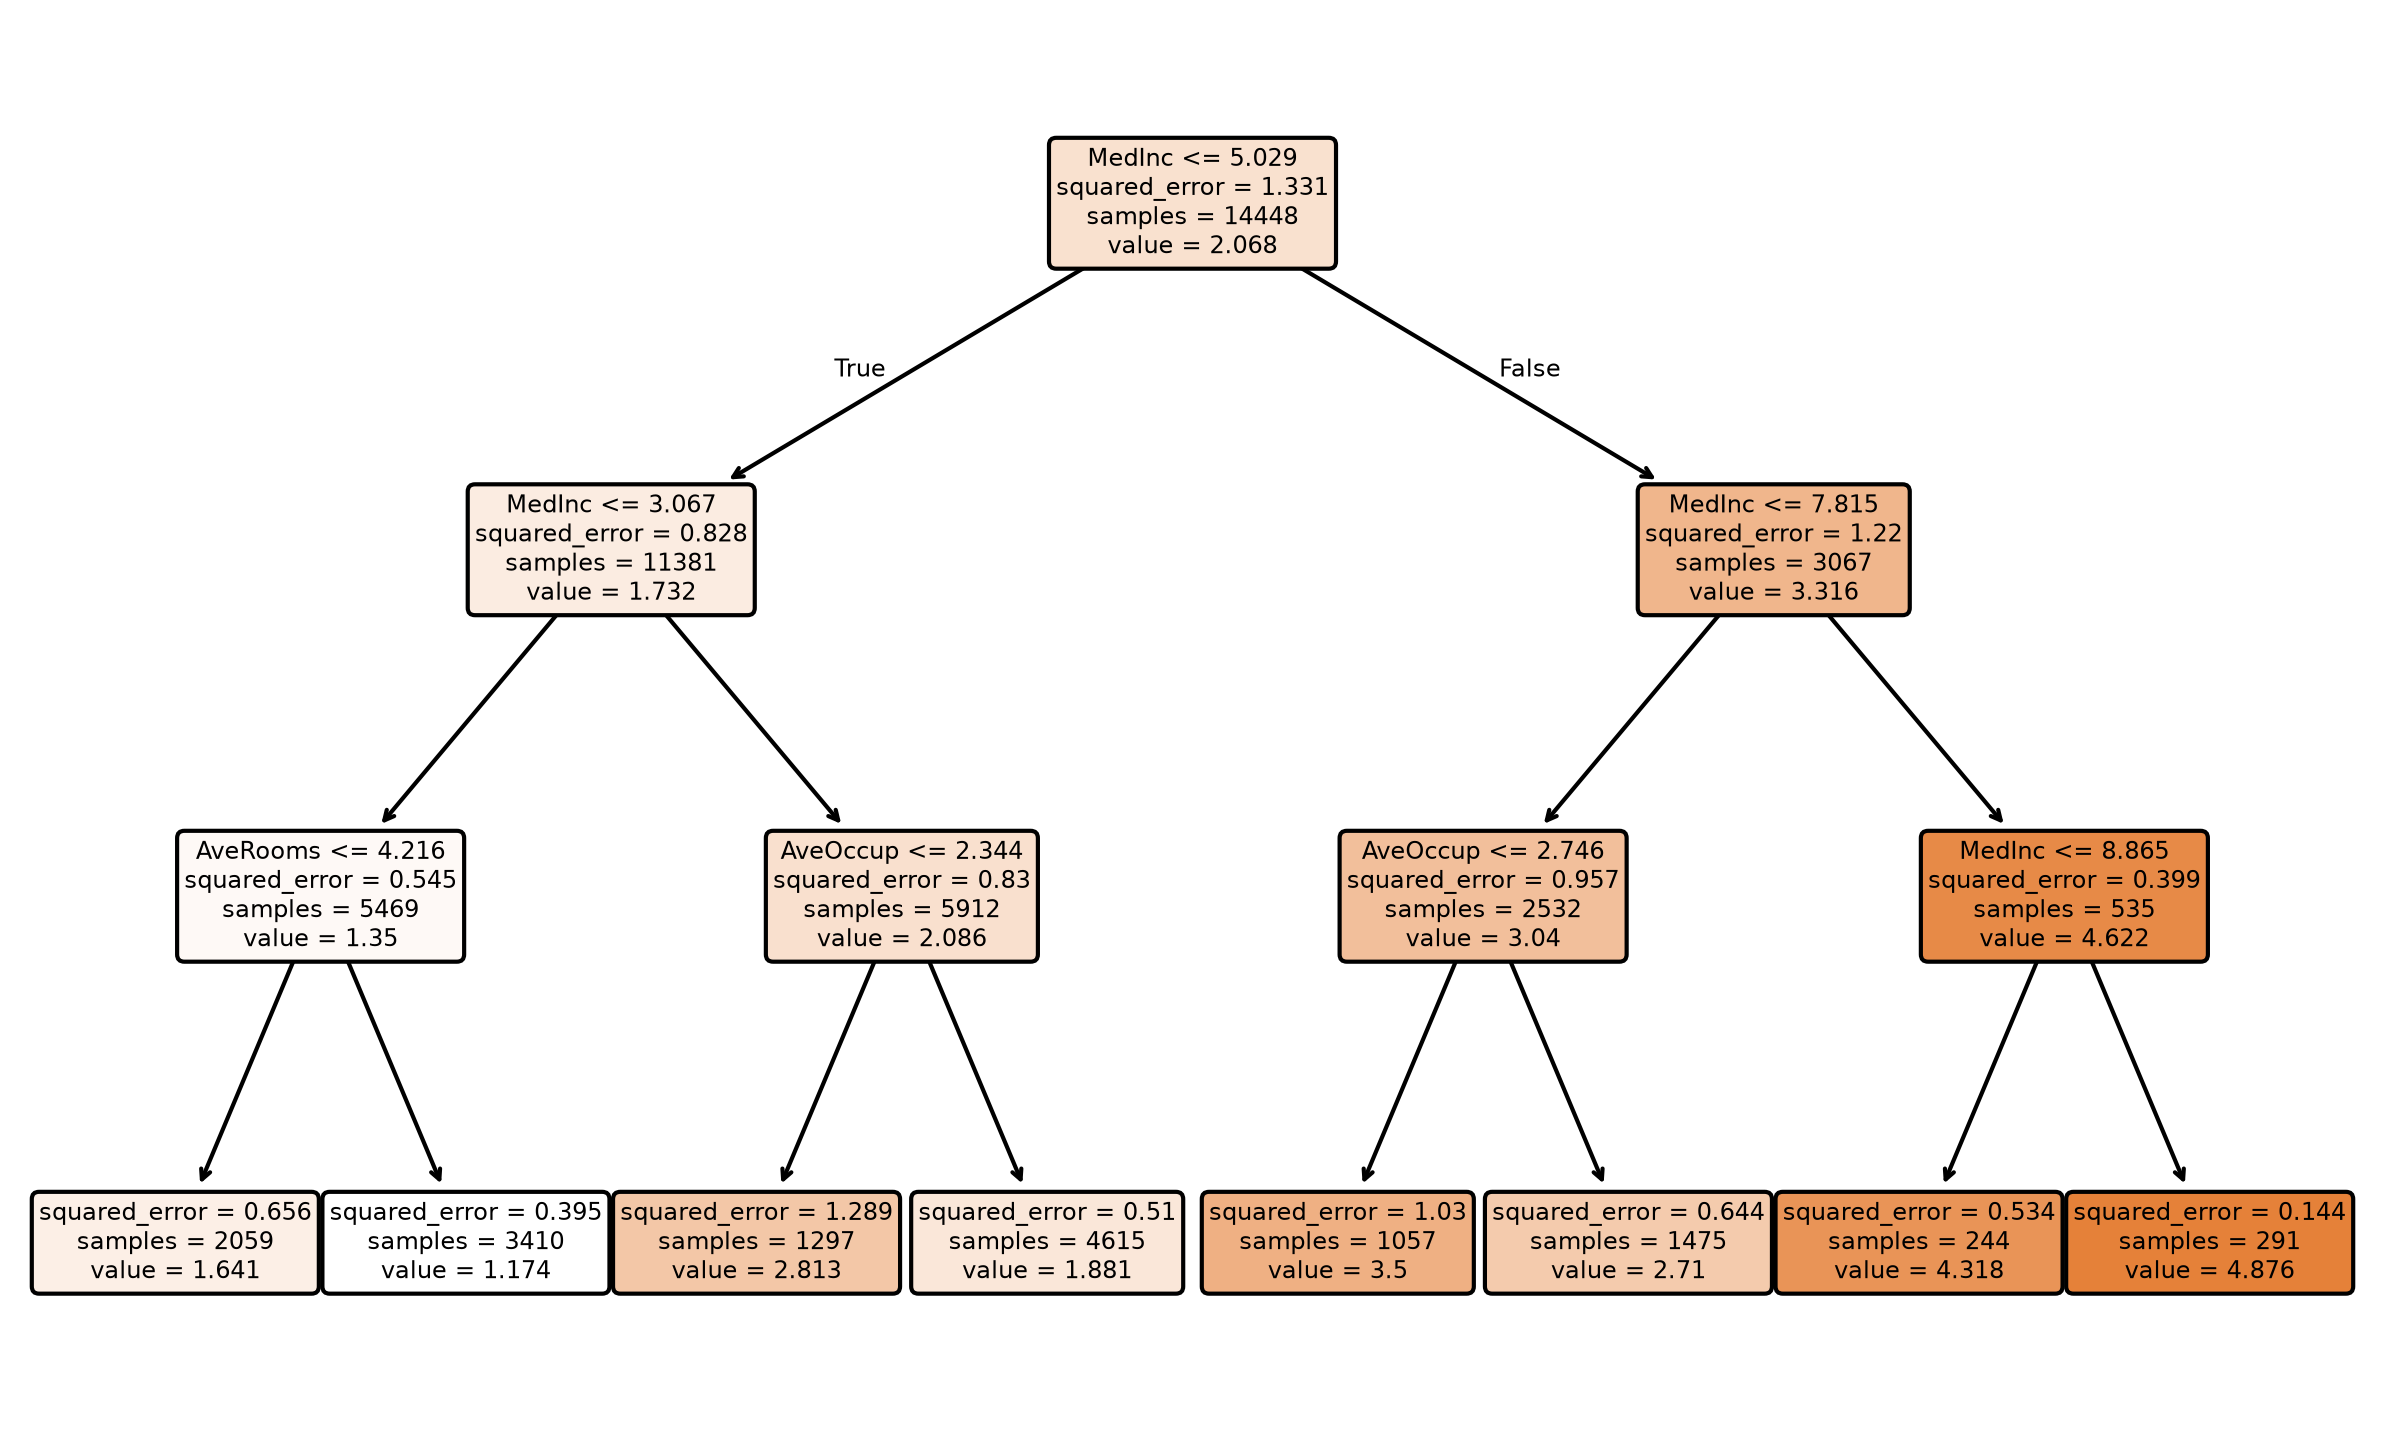

In [9]:
# Let's look at the result above in the context of the tree

plt.figure(figsize=(10, 6), dpi=300)

plot_tree(
    decision_tree = tree,
    feature_names=X_train.columns.to_list(),
    filled=True,
    rounded=True,
)

plt.show()

## Node contributions

In [10]:
first_split = 1.732 - 2.068
second_split = 2.086 - 1.732
third_split = 1.881 - 2.086

first_split, second_split, third_split

(-0.3360000000000001, 0.35399999999999987, -0.20499999999999985)

In [11]:
# prediction

y_train.mean() + first_split + second_split + third_split

np.float64(1.8812462451550387)

## Feature contribution

In [12]:
MedInc = first_split + second_split
AveOccup = third_split

MedInc, AveOccup

(0.017999999999999794, -0.20499999999999985)

In [13]:
# prediction

y_train.mean() + MedInc + AveOccup

np.float64(1.8812462451550387)

In [14]:
tree.predict(X_test.loc[sample_id].to_frame().T)

array([1.88137512])

I spent hours trying to see if there was an easy way to calculate feature contributions with sklearn, and I failed. So we are going to outsource the job to eli5, which decomposes a tree's prediction into per-feature contributions (the same way treeinterpreter used to — treeinterpreter is unmaintained and no longer works with modern numpy).

## Feature contributions with eli5

In [15]:
import eli5

In [16]:
row = X_test.loc[sample_id]

contrib = eli5.explain_prediction_df(tree, row, feature_names=list(X_train.columns))
contrib

,target,feature,weight,value
0,y,<BIAS>,2.068246,1.000000
1,y,MedInc,0.017508,4.151800
2,y,AveOccup,-0.204379,4.180593


A quick note on the columns above:

- **`value`** is simply the observation's raw input for that feature (for the `<BIAS>` row this is just a placeholder `1.0`, not a real feature value).
- **`weight`** is the contribution, in the units of the target (house price), that each feature adds or subtracts from the baseline. `<BIAS>`'s weight is the baseline itself -- the prediction you'd make with no feature information, i.e. the mean target value at the tree's root node (`y_train.mean()`).
- The `weight` column always **sums up to the model's prediction** for that observation: `<BIAS> + sum(feature weights) == tree.predict(row)`.

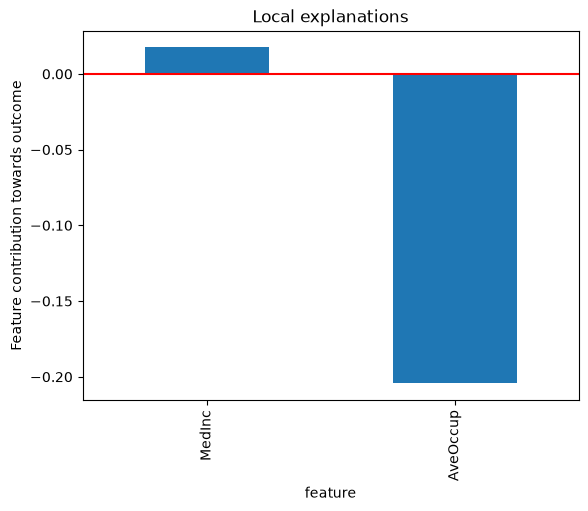

In [17]:
contrib.set_index("feature")["weight"].drop("<BIAS>").plot.bar()
plt.axhline(y=0, color='r', linestyle='-')
plt.ylabel("Feature contribution towards outcome")
plt.title("Local explanations")
plt.show()

In [18]:
tree.predict(row.to_frame().T)

array([1.88137512])

In [19]:
# let's look at another observation

row = X_test.iloc[1]

contrib = eli5.explain_prediction_df(tree, row, feature_names=list(X_train.columns))
contrib

,target,feature,weight,value
0,y,<BIAS>,2.068246,1.000000
1,y,MedInc,0.971845,5.779600
2,y,AveOccup,-0.329753,3.020979


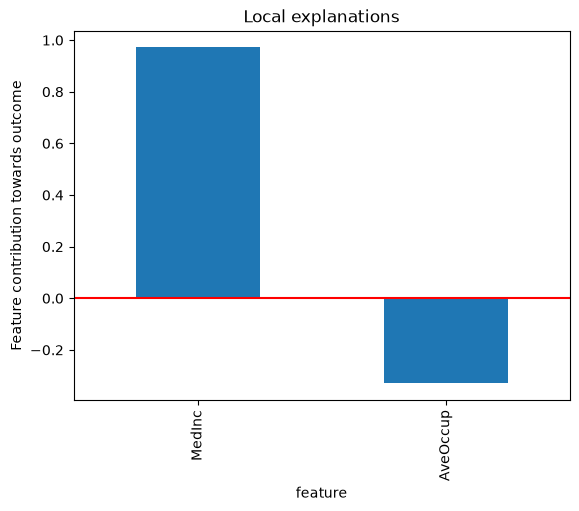

In [20]:
contrib.set_index("feature")["weight"].drop("<BIAS>").plot.bar()
plt.axhline(y=0, color='r', linestyle='-')
plt.ylabel("Feature contribution towards outcome")
plt.title("Local explanations")
plt.show()

In [21]:
tree.predict(row.to_frame().T)

array([2.71033782])

Note that the decrease in price is not proportional to the AveOccup, because this is not a linear model.